# Figure 3: HH Graphs for the Kim&ndash;Forger SNF Model

This notebook reproduces the HH graphs for the Kim&ndash;Forger SNF model that are shown in Figure 3 of the manuscript. In terms of methodology, this task does not require anything new. These are just zoomed-in versions of Figure 2. For the purpose of completeness, how this was done is illustrated below. 

In [65]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from kim_forger_snf.hopf import hopf_curve

The next code cell loads the IPH curve data that was generated in `/notebooks/figure2_parameter_space.ipynb`, then generates data for the Hopf curve. 

In [66]:
iph_df = pd.read_csv("../data/iph_curves.csv")
A_LOWER = 1e-6
A_UPPER = 0.125 
DA_HOPF = 1e-4  
A_hopf = np.arange(A_LOWER, A_UPPER + DA_HOPF, DA_HOPF)
Kd_hopf = hopf_curve(A_hopf)

The helper function defined in the next code cell, `plot_hh_graph()`, plots the Hopf curve and any IPH curves that have points in specified window. The resulting plot is then restricted to the specified window. 

In [67]:
def plot_hh_graph(ax, xlim, ylim):
    # plot the Hopf curve
    ax.plot(Kd_hopf, A_hopf, "g-", linewidth = 2, label = r"$\mathcal{H}$")

    for branch, group in iph_df.groupby("branch", sort = True):
        group = group.sort_values("K_d")

        # determine whether the IPH curve lies in the window 
        in_window = (
            group["K_d"].between(xlim[0], xlim[1])
            & group["A"].between(ylim[0], ylim[1])
        )

        # only plot the IPH curve if it has points within the window
        if in_window.any():
            ax.plot(
                group["K_d"],
                group["A"],
                'r-',
                linewidth = 2,
                label = r"$\mathcal{S}$" if r"$\mathcal{S}$" not in ax.get_legend_handles_labels()[1] else None,
            )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$K_d$", fontsize = 24)
    ax.set_ylabel(r"$A$", fontsize = 24)
    ax.tick_params(axis = "both", which = "major", labelsize = 20)
    ax.xaxis.set_major_locator(MaxNLocator(nbins = 2))
    ax.xaxis.get_offset_text().set_fontsize(20)
    ax.yaxis.get_offset_text().set_fontsize(20)
    ax.legend(fontsize = 20)

The last code cell of this notebook uses `plot_hh_graph()` to reproduce Subfigures 3a and 3b from the manuscript and save them as separate PNG files. 

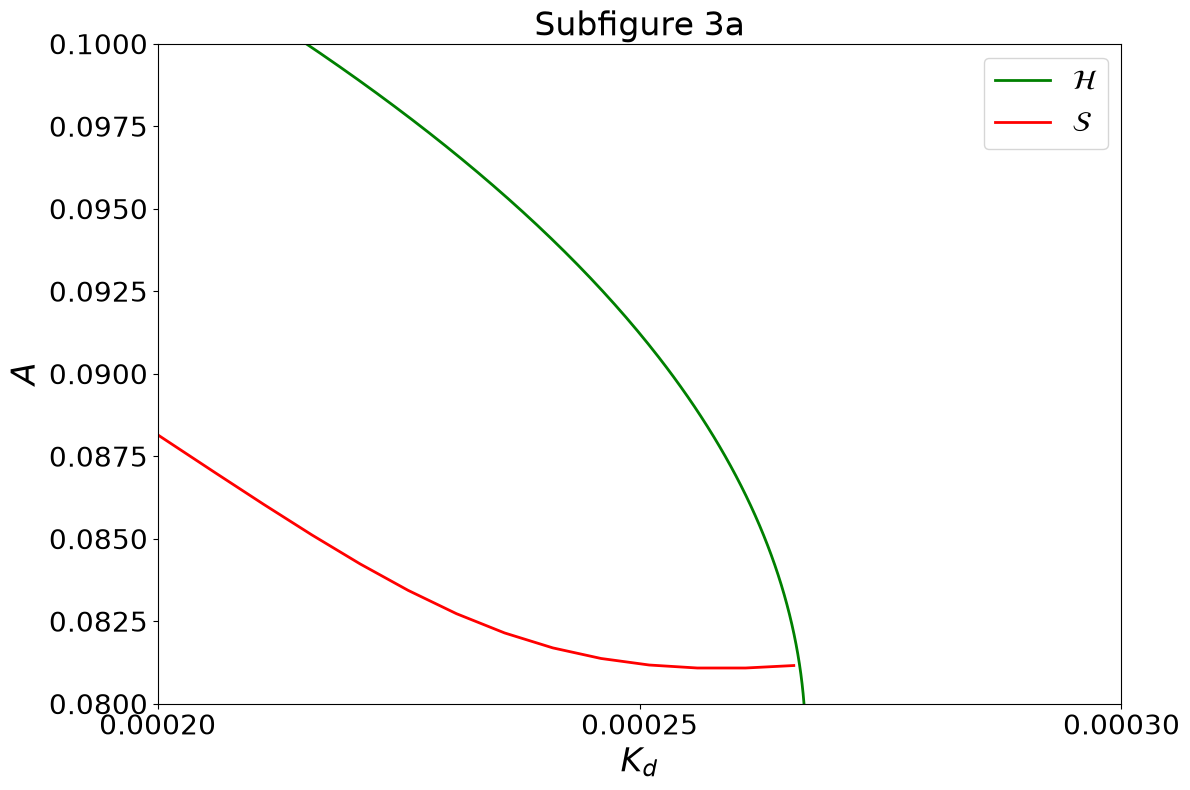

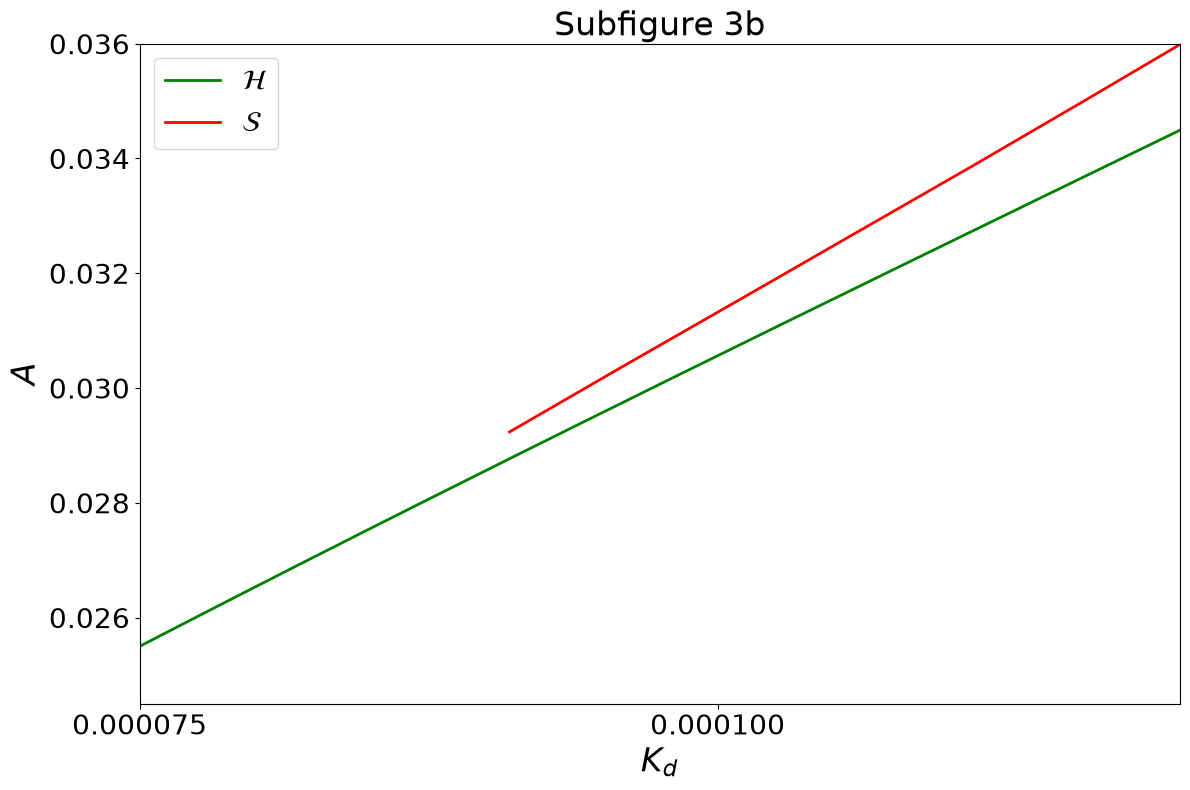

In [68]:
fig_3a, ax_3a = plt.subplots(figsize = (12, 8))

plot_hh_graph(
    ax_3a,
    xlim = (2e-4, 3e-4),
    ylim = (8e-2, 1e-1),
)
ax_3a.set_title("Subfigure 3a", fontsize = 24)
fig_3a.tight_layout()
fig_3a.savefig("../outputs/figure3a.png", dpi = 300, bbox_inches = "tight")

fig_3b, ax_3b = plt.subplots(figsize = (12, 8))
plot_hh_graph(
    ax_3b,
    xlim = (7.5e-5, 1.2e-4),
    ylim = (2.45e-2, 3.6e-2),
)
ax_3b.set_title("Subfigure 3b", fontsize = 24)
fig_3b.tight_layout()
fig_3b.savefig("../outputs/figure3b.png", dpi = 300, bbox_inches = "tight")